# Project 1 Part 1 by Prathamesh Uravane UID-122016187



## **1 Decision Tree and Random Forest Classifiers**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import joblib
import tqdm

In [2]:
#Import data
df=pd.read_csv('heart-disease-classification.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [7]:
#labels
y=df['HeartDisease']
y.unique()

array([0, 1], dtype=int64)

Text(0.5, 1.0, 'HeartDisease')

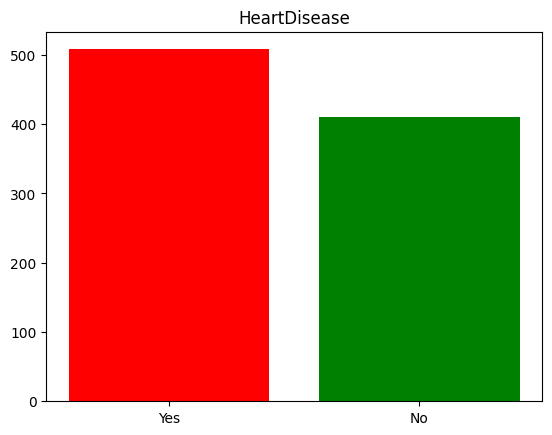

In [8]:
#plot graph
plt.bar(['Yes', 'No'],[len(y[y==1]),len(y[y==0])],color=['red','green'])
plt.title('HeartDisease')

In [9]:
#convert Numerical data into int representationof of unique categories

# Convert Age to Age_cat
df['Age_cat'] = pd.cut(df['Age'],
                       bins=[0, 40, 55, float('inf')],
                       labels=['Young', 'Mid', 'Older'],
                       right=True)

# Convert RestingBP to RestingBP_cat
df['RestingBP_cat'] = pd.cut(df['RestingBP'],
                             bins=[0, 120, 140, float('inf')],
                             labels=['Low', 'Normal', 'High'],
                             right=True)

# Convert Cholesterol to Cholesterol_cat
df['Cholesterol_cat'] = pd.cut(df['Cholesterol'],
                               bins=[0, 200, float('inf')],
                               labels=['Normal', 'High'],
                               right=True)

# Convert MaxHR to MaxHR_cat
df['MaxHR_cat'] = pd.cut(df['MaxHR'],
                         bins=[0, 140, 165, float('inf')],
                         labels=['Low', 'Normal', 'High'],
                         right=True)


In [10]:
#Replace numerical columns with categorical columns
df['Age']=df['Age_cat']
df['RestingBP']=df['RestingBP_cat']
df['Cholesterol']=df['Cholesterol_cat']
df['MaxHR']=df['MaxHR_cat']
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_cat,RestingBP_cat,Cholesterol_cat,MaxHR_cat
0,Young,M,ATA,Normal,High,0,Normal,High,N,0.0,Up,0,Young,Normal,High,High
1,Mid,F,NAP,High,Normal,0,Normal,Normal,N,1.0,Flat,1,Mid,High,Normal,Normal
2,Young,M,ATA,Normal,High,0,ST,Low,N,0.0,Up,0,Young,Normal,High,Low
3,Mid,F,ASY,Normal,High,0,Normal,Low,Y,1.5,Flat,1,Mid,Normal,High,Low
4,Mid,M,NAP,High,Normal,0,Normal,Low,N,0.0,Up,0,Mid,High,Normal,Low


In [11]:
df.to_csv('HeartDiseaseData.csv', index=False)

In [12]:
df.nunique()

Age                 3
Sex                 2
ChestPainType       4
RestingBP           3
Cholesterol         2
FastingBS           2
RestingECG          3
MaxHR               3
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
Age_cat             3
RestingBP_cat       3
Cholesterol_cat     2
MaxHR_cat           3
dtype: int64

Now columns [Age, RestingBP, Cholesterol,and MaxHR] as few unique values 

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Age              918 non-null    category
 1   Sex              918 non-null    object  
 2   ChestPainType    918 non-null    object  
 3   RestingBP        917 non-null    category
 4   Cholesterol      746 non-null    category
 5   FastingBS        918 non-null    int64   
 6   RestingECG       918 non-null    object  
 7   MaxHR            918 non-null    category
 8   ExerciseAngina   918 non-null    object  
 9   Oldpeak          918 non-null    float64 
 10  ST_Slope         918 non-null    object  
 11  HeartDisease     918 non-null    int64   
 12  Age_cat          918 non-null    category
 13  RestingBP_cat    917 non-null    category
 14  Cholesterol_cat  746 non-null    category
 15  MaxHR_cat        918 non-null    category
dtypes: category(8), float64(1), int64(2), object

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for c in df.columns:
    if df[c].dtype=='object' or df[c].dtype=='category':
        df[c] = le.fit_transform(df[c])

    
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_cat,RestingBP_cat,Cholesterol_cat,MaxHR_cat
0,2,1,1,2,0,0,1,0,0,0.0,2,0,2,2,0,0
1,0,0,2,0,1,0,1,2,0,1.0,1,1,0,0,1,2
2,2,1,1,2,0,0,2,1,0,0.0,2,0,2,2,0,1
3,0,0,0,2,0,0,1,1,1,1.5,1,1,0,2,0,1
4,0,1,2,0,1,0,1,1,0,0.0,2,0,0,0,1,1


In [15]:
#Labels
X=df.drop(columns='HeartDisease')
y=df['HeartDisease']


In [16]:
# Initialize accuracy trackers
results = {
    'dt_200': [],
    'rf_200': [],
    'dt_10': [],
    'rf_10': []
}


In [17]:
for i in range(20):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=None)  #train test split
    
    # min_samples_split = 200 
    dt_200 = DecisionTreeClassifier(min_samples_split=200, random_state=42)
    rf_200 = RandomForestClassifier(n_estimators=250, min_samples_split=200, random_state=42)
    
    dt_200.fit(X_train, y_train)
    rf_200.fit(X_train, y_train)
    
    dt_pred_200 = dt_200.predict(X_test)
    rf_pred_200 = rf_200.predict(X_test)
    
    results['dt_200'].append(accuracy_score(y_test, dt_pred_200))
    results['rf_200'].append(accuracy_score(y_test, rf_pred_200))
    
     # Save models from first iteration only
    if i == 0:
        joblib.dump(dt_200, 'decision_tree_min200.pkl')
        joblib.dump(rf_200, 'random_forest_250trees_min200.pkl')
        
        
     #min_samples_split = 10
    dt_10 = DecisionTreeClassifier(min_samples_split=10, random_state=42)
    rf_10 = RandomForestClassifier(n_estimators=250, min_samples_split=10, random_state=42)

    dt_10.fit(X_train, y_train)
    rf_10.fit(X_train, y_train)

    dt_pred_10 = dt_10.predict(X_test)
    rf_pred_10 = rf_10.predict(X_test)

    results['dt_10'].append(accuracy_score(y_test, dt_pred_10))
    results['rf_10'].append(accuracy_score(y_test, rf_pred_10))




    

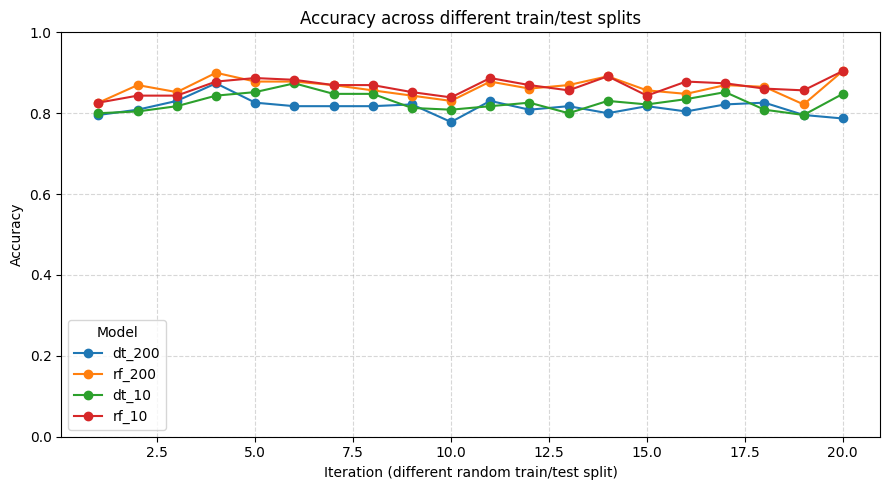

In [18]:
import matplotlib.pyplot as plt

num_runs = len(next(iter(results.values())))
iters = np.arange(1, num_runs + 1)

plt.figure(figsize=(9, 5))
for model_name, scores in results.items():
    plt.plot(iters, scores, marker='o', linewidth=1.5, label=model_name)

plt.title('Accuracy across different train/test splits')
plt.xlabel('Iteration (different random train/test split)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [19]:
# Summary 
print("Average Test Accuracies over 20 runs:")
print(f"Decision Tree (min_samples_split=200): {np.mean(results['dt_200']):.4f}")
print(f"Random Forest (250 trees, min_samples_split=200): {np.mean(results['rf_200']):.4f}")
print(f"Decision Tree (min_samples_split=10): {np.mean(results['dt_10']):.4f}")
print(f"Random Forest (250 trees, min_samples_split=10): {np.mean(results['rf_10']):.4f}")


Average Test Accuracies over 20 runs:
Decision Tree (min_samples_split=200): 0.8148
Random Forest (250 trees, min_samples_split=200): 0.8635
Decision Tree (min_samples_split=10): 0.8272
Random Forest (250 trees, min_samples_split=10): 0.8657


In [30]:
results.describe(include='all')

,k,accuracy
count,18.000000,18.000000
mean,11.500000,0.857246
std,5.338539,0.013688
min,3.000000,0.830435
25%,7.250000,0.848913
50%,11.500000,0.856522
75%,15.750000,0.864130
max,20.000000,0.882609


### Discussion of min_samples_split and Model Comparison

1.When min_samples_split changed from 200 → 10, both models had slightly higher accuracy.

2.Smaller split made trees deeper and learned more details.

3.Accuracy change was small, only a few percent.

4.Random Forest was better than Decision Tree overall.

5.It was also more stable and less overfitting.

6.Lower split helped a bit, but Random Forest stayed best.
